# FORCE Level 2 processing using openEO on CDSE

### Purpose

The [Earth Observation Application Package (EOAP)](https://docs.ogc.org/bp/20-089r1.html) and surrounding tools implemented in the [`apex-force-openeo`](https://github.com/bcdev/apex-force-openeo) make it possible to use the [FORCE](https://force-eo.readthedocs.io/en/latest/) EO processing engine on the [Copernicus Data Space Ecosystem (CDSE)](https://dataspace.copernicus.eu/) using the [openEO](https://openeo.dataspace.copernicus.eu/) API.

> This notebook serves to showcase a simple workflow to run FORCE level 2 on CDSE and download the processed results.

Please note that this is neither a tutorial for FORCE nor for openEO, please have a look at the Furhter Reading section below, if you are unfamiliar with either. The basic openEO client operations will be explained, FORCE will be used without further explanation. Please refer to the [FORCE documentation](https://force-eo.readthedocs.io/en/latest/components/lower-level/level2/) for the level 2 processing system to learn more.


### Prerequisites

In order to run this notebook, you need to have a CDSE account and sufficient openEO credits to run the jobs. Please note that CDSE provides a contigent of free credits each month, so you should be able to run the notebook if you haven't used up your credits with no additional cost.

> At the time of writing (2026-04-20) the query process `query_stac` requires an account for the staging deployment of the openEO backend. However, it should be available on the production deployment soon.

### Content

1. Connect to OpenEO backend
2. Make a query to the CDSE STAC catalog to determine input products
3. Run the FORCE l2ps on CDSE using OpenEO and the FORCE EOAP
4. Download processed products
5. Visualize the results

### Citation and Acknowledgement

When using the FORCE processing engine, please make sure to properly [cite and acknowledge](https://force-eo.readthedocs.io/en/latest/policy/citation.html)
the software and its related [scientific publications](https://force-eo.readthedocs.io/en/latest/refs.html#refs) .
The implementation as EOAP was performed in the context of ESA's [APEx](https://apex.esa.int/) initiative.

### Further reading

**APEx**

1. [Project website](https://apex.esa.int/)
2. [Documentation Portal](https://esa-apex.github.io/apex_documentation/)

**FORCE**

1. [Documentation](https://force-eo.readthedocs.io/en/latest/index.html)
1. [Level 2 processing system](https://force-eo.readthedocs.io/en/latest/components/lower-level/level2/)
1. [Citation and acknowledgement](https://force-eo.readthedocs.io/en/latest/policy/citation.html)


**openEO**

1. [openEO on CDSE](https://documentation.dataspace.copernicus.eu/APIs/openEO/openEO.html)
1. [Credit Usage on CDSE](https://documentation.dataspace.copernicus.eu/APIs/openEO/credit_usage.html)
1. [openEO project website](https://openeo.org/)
1. [openEO Python Client documentation](https://open-eo.github.io/openeo-python-client/)


### Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import copy
import json

import openeo
import contextily
import shapely
import pystac
import matplotlib.pyplot as plt
import rioxarray

import force_example_utils as utils

### Area of Interest

For this example, we selected a small area around Ancona on Italy's Adriatic Sea coast. 
Here, we quickly visualize the area of interest.

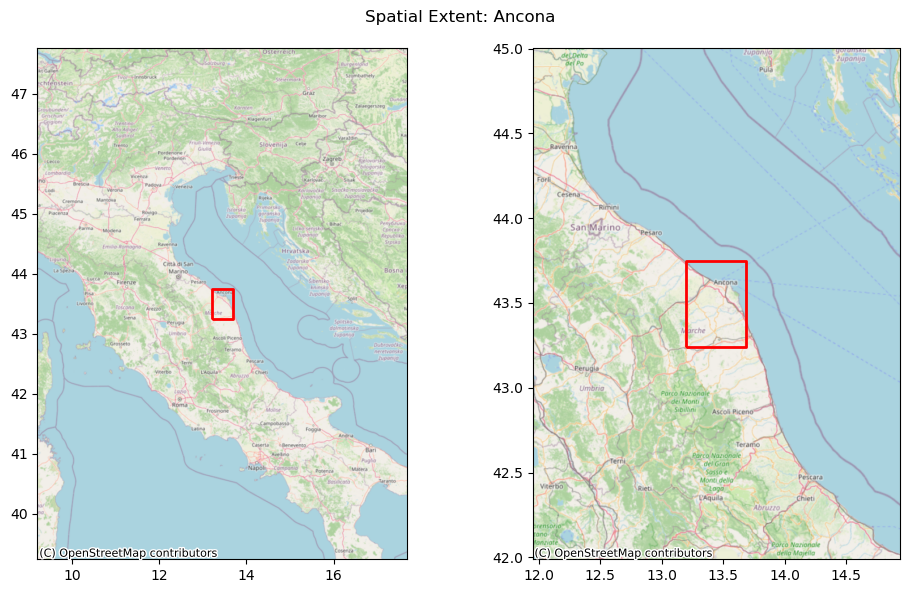

In [3]:
w,s,e,n = 13.2, 43.239, 13.688, 43.75
spatial_extent = { "west": w, "south": s, "east": e, "north": n}
aoi_name = "Ancona"
temporal_extent=["2026-04-19", "2026-04-20"]

utils.plot_area_of_interest(
    w=w,
    s=s,
    e=e,
    n=n,
    large_context=4,
    figsize=(10, 6),
    title=f"Spatial Extent: {aoi_name}"
)

### Connect to the OpenEO backend

In order to send requests and start jobs on the openEO backend, we must first authenticate. If you haven't recently logged into the openEO backend, this cell will prompt you to authenticate. Please click the link produced in the cell to log in.

> If you don't have a CDSE account yet, please [create one first](https://documentation.dataspace.copernicus.eu/Registration.html)!

In [4]:
backend_url = "openeo-staging.dataspace.copernicus.eu"
connection = openeo.connect(backend_url).authenticate_oidc()

Authenticated using refresh token.


### Query the CDSE STAC catalog

To determine the inputs to process with FORCE, we need to determine a number of STAC Items, describing our input products. We can do this directly through openEO, by using the `query_stac` process. Alternatively, you can determine a suitable STAC Item, Collection or Catalog or a STAC API ItemCollection independently and pass it to the FORCE level 2 process in the next step.

As spatial extent, pass a dictionary with keys `["west", "south", "east", "north"]` (and optionally, `"crs"`), as we have defined above:

In [5]:
L1C_COLLECTION_URL = "https://stac.dataspace.copernicus.eu/v1/collections/sentinel-2-l1c"

query_pg = connection.datacube_from_process(
    "query_stac",
    url=L1C_COLLECTION_URL,
    temporal_extent=temporal_extent,
    spatial_extent=spatial_extent
)

### Inspect query results (optional)

This step is optional, but you may be interested which products were selected for input. The `execute` step evalutes the process graph and loads the response as JSON. For the query process, the result is an [ItemCollection](https://github.com/radiantearth/stac-api-spec/blob/main/fragments/itemcollection/README.md) as defined by the STAC API.

You could alternatively directly connect the query process with the FORCE level 2 process. In that case, pass `query_pg` to the force level 2 process (below) instead of `query_res`.

In [6]:
query_res = connection.execute(query_pg)

In [7]:
print(f"The query returned {len(query_res['features'])} product(s):")
print(utils.format_list([f["id"] for f in query_res["features"]]), "\n")
item = pystac.Item.from_dict(query_res["features"][0])
item

The query returned 2 product(s):

 - S2B_MSIL1C_20260419T100019_N0512_R122_T33TUJ_20260419T133413
 - S2B_MSIL1C_20260419T100019_N0512_R122_T33TUH_20260419T133413 



<Item id=S2B_MSIL1C_20260419T100019_N0512_R122_T33TUJ_20260419T133413>

### Running FORCE level 2 (l2ps)

Now that we have selected the input files, we can pass the selection to the FORCE level 2 process. The process will automatically download the necessary files.
As usual in openEO, we can chain processes. In this case, we can connect the query directly to FORCE level2, without evaluating it.
Note that we cab use the openEO process graph `query_pg` as a parameter.

#### Note:

> **You will be able to use a dedicated process `force_level2` instead of `run_cwl_to_stac` which will make it unnecessary to explicitly pass the CWL document in the future.
Until this process is available on the CDSE openEO backend, `run_cwl_to_stac` can be used.**

#### Observing the progress on openEO

You can track the progress of your job by logging into the [openEO web interface](https://openeo.dataspace.copernicus.eu/)

Alternatively, in a separate Python shell / notebook, you can run the following snippet to get access to the logs as a Python list.
You can find out the job id from the next cell below.

Please be aware that the output from CWL jobs is not optimized for openEO logs, so the logs may look a little bit messy and fragmented. 
However, they can be a valuable source of information to debug issues.

```Python
JOB_ID = ... # see the output from `l2_job.start_and_wait()` below)
connection = ... # connect to the same backend
l2_job = connection.job(JOB_ID)
l2_logs = l2_job.logs()
print("\n".join(l2_logs[:20]))
```

#### How does the code work?

First, we load the [Common Workflow Language (CWL)](https://www.commonwl.org/) document `force-level2.cwl` as a string and pass it to openEO. This CWL document is an EOAP, together with the docker image referenced within it.
In the CWL, the inputs, outputs and steps of the FORCE level 2 workflow are specified. Simplified, these steps are:

1. `staging` Download the inputs defined by the query results
2. `force_level2` Run FORCE level 2 and create STAC metadata for it

Once the FORCE custom process is available, it will no longer be necessary to specify 


In [8]:
cwl_text = Path("force-level2.cwl").read_text()
context = dict(
    #stac_document=query_pg,
    stac_document=query_res,
)

stac_resource = openeo.rest.stac_resource.StacResource(
    graph=openeo.internal.graph_building.PGNode(
        process_id="run_cwl_to_stac",
        arguments={
            #"cwl_url": cwl_text,
            "cwl": cwl_text,
            "context": context,
        }
    ),
    connection=connection,
)
l2_job = stac_resource.create_job(title=f"FORCE level 2 - {aoi_name}")
print(f"Job id: '{l2_job.job_id}'")
l2_job.start_and_wait()

Job id: 'j-26042012445446ed89ff605872f0ee56'
0:00:00 Job 'j-26042012445446ed89ff605872f0ee56': send 'start'
0:00:13 Job 'j-26042012445446ed89ff605872f0ee56': created (progress 0%)
0:00:19 Job 'j-26042012445446ed89ff605872f0ee56': running (progress 2.7%)
0:00:25 Job 'j-26042012445446ed89ff605872f0ee56': running (progress 3.8%)
0:00:34 Job 'j-26042012445446ed89ff605872f0ee56': running (progress 5.0%)
0:00:44 Job 'j-26042012445446ed89ff605872f0ee56': running (progress 6.5%)
0:00:56 Job 'j-26042012445446ed89ff605872f0ee56': running (progress 8.3%)
0:01:12 Job 'j-26042012445446ed89ff605872f0ee56': running (progress 10.5%)
0:01:32 Job 'j-26042012445446ed89ff605872f0ee56': running (progress 13.0%)
0:01:56 Job 'j-26042012445446ed89ff605872f0ee56': running (progress 15.9%)
0:02:26 Job 'j-26042012445446ed89ff605872f0ee56': running (progress 19.3%)
0:03:03 Job 'j-26042012445446ed89ff605872f0ee56': running (progress 23.2%)
0:03:50 Job 'j-26042012445446ed89ff605872f0ee56': running (progress 27.6%)


<BatchJob job_id='j-26042012445446ed89ff605872f0ee56'>

In [9]:
logs = l2_job.logs()

In [10]:
logs

[{'id': '[1776689121051, 892773]',
  'time': '2026-04-20T12:45:21.051Z',
  'level': 'info',
  'message': 'Starting batch job os.getpid()=85: start 2026-04-20 12:45:21.051149'},
 {'id': '[1776689121051, 894152]',
  'time': '2026-04-20T12:45:21.051Z',
  'level': 'info',
  'message': "batch_job.py sys.version='3.11.7 (main, Aug 23 2024, 00:00:00) [GCC 11.4.1 20231218 (Red Hat 11.4.1-3)]'"},
 {'id': '[1776689121683, 599579]',
  'time': '2026-04-20T12:45:21.683Z',
  'level': 'info',
  'message': 'Loading custom processes from /opt/openeo-geopyspark-k8s-custom-processes/src/openeo_geopyspark_k8s_custom_processes/custom_processes.py'},
 {'id': '[1776689121685, 420657]',
  'time': '2026-04-20T12:45:21.685Z',
  'level': 'info',
  'message': 'Overriding process sar_backscatter (namespace backend)'},
 {'id': '[1776689121685, 440346]',
  'time': '2026-04-20T12:45:21.685Z',
  'level': 'info',
  'message': 'Overriding process sar_backscatter (namespace backend)'},
 {'id': '[1776689121685, 482636]',
  'time': '2026-04-20T12:45:21.685Z',
  'level': 'info',
  'message': "load_custom_processes: exec loaded '/opt/openeo-geopyspark-k8s-custom-processes/src/openeo_geopyspark_k8s_custom_processes/custom_processes.py'"},
 {'id': '[1776689132583, 377118]',
  'time': '2026-04-20T12:45:32.583Z',
  'level': 'info',
  'message': 'Job spec: {\n "process_graph": {\n  "runcwltostac1": {\n   "process_id": "run_cwl_to_stac",\n   "arguments": {\n    "context": {\n     "stac_document": {\n      "features": [\n       {\n        "assets": {\n         "B01": {\n          "alternate": {\n           "https": {\n            "alternate:name": "HTTPS",\n            "auth:refs": [\n             "oidc"\n            ],\n            "href": "https://download.dataspace.copernicus.eu/odata/v1/Products(4b247a0e-dda8-4859-bd03-7dbb48b53d14)/Nodes(S2B_MSIL1C_20260419T100019_N0512_R122_T33TUJ_20260419T133413.SAFE)/Nodes(GRANULE)/Nodes(L1C_T33TUJ_A047624_20260419T100036)/Nodes(IMG_DATA)/Nodes(T33TUJ_20260419T100019_B01.jp2)/$value",\n            "storage:refs": []\n           }\n          },\n          "alternate:name": "S3",\n          "auth:refs": [\n           "s3"\n          ],\n          "bands": [\n           {\n            "description": "Coastal aerosol (band 1)",\n            "eo:center_wavelength": 0.443,\n            "eo:common_name": "coastal",\n            "eo:full_width_half_max": 0.228,\n            "name": "B01"\n           }\n          ],\n          "data_type": "uint16",\n          "file:checksum": "1620d422414254576acbe56650410e84f4e7f4ab3a4d42fb1ba586aee8db9f77d56d",\n          "file:local_path": "S2B_MSIL1C_20260419T100019_N0512_R122_T33TUJ_20260419T133413.SAFE/GRANULE/L1C_T33TUJ_A047624_20260419T100036/IMG_DATA/T33TUJ_20260419T100019_B01.jp2",\n          "file:size": 3754255,\n          "gsd": 60,\n          "href": "s3://eodata/Sentinel-2/MSI/L1C/2026/04/19/S2B_MSIL1C_20260419T100019_N0512_R122_T33TUJ_20260419T133413.SAFE/GRANULE/L1C_T33TUJ_A047624_20260419T100036/IMG_DATA/T33TUJ_20260419T100019_B01.jp2",\n          "nodata": 0,\n          "proj:bbox": [\n           300000,\n           4790220,\n           409800,\n           4900020\n          ],\n          "proj:code": "EPSG:32633",\n          "proj:shape": [\n           1830,\n           1830\n          ],\n          "proj:transform": [\n           60,\n           0,\n           300000,\n           0,\n           -60,\n           4900020\n          ],\n          "raster:offset": -0.1,\n          "raster:scale": 0.0001,\n          "roles": [\n           "data",\n           "reflectance"\n          ],\n          "storage:refs": [\n           "cdse-s3",\n           "creodias-s3"\n          ],\n          "title": "Coastal aerosol (band 1) - 60m",\n          "type": "image/jp2",\n          "view:azimuth": 124.881886924458,\n          "view:incidence_angle": 3.73721651278343\n         },\n         "B02": {\n          "alternate": {\n           "https": {\n            "alternate:name": "HTTPS",\n            "au

## Download the results

Assets from the completed processing can be downloaded using openEO's `get_results` and `download_files` methods. The FORCE directory structure will automatically be respected. After executing the `download_files` process, check the `force-level2-assets` (or the name you specified) directory next to this notebook for the results.
If you want to download only partial results, you can use the [`download_file`](https://open-eo.github.io/openeo-python-client/api.html#openeo.rest.job.JobResults.download_file) (singular) process instead.

In [11]:
l2_results = l2_job.get_results()
l2_results

<JobResults for job 'j-26042012445446ed89ff605872f0ee56'>

In [12]:
assets_path = Path("force-level2-assets")
l2_results.download_files(assets_path)

[PosixPath('force-level2-assets/europe/X0032_Y0030/20260419_LEVEL2_SEN2B_BOA.tif'),
 PosixPath('force-level2-assets/europe/X0032_Y0030/20260419_LEVEL2_SEN2B_OVV.jpg'),
 PosixPath('force-level2-assets/europe/X0032_Y0030/20260419_LEVEL2_SEN2B_QAI.tif'),
 PosixPath('force-level2-assets/europe/X0033_Y0030/20260419_LEVEL2_SEN2B_BOA.tif'),
 PosixPath('force-level2-assets/europe/X0033_Y0030/20260419_LEVEL2_SEN2B_OVV.jpg'),
 PosixPath('force-level2-assets/europe/X0033_Y0030/20260419_LEVEL2_SEN2B_QAI.tif'),
 PosixPath('force-level2-assets/europe/datacube-definition.prj'),
 PosixPath('force-level2-assets/job-results.json')]

### Visualize

Now that we have downloaded the results, we may continue the analysis of the data as usual. As a small example, we generate an RGB of the results:

In [30]:
X, Y = "0032", "0030"
tiff_path = assets_path / "europe" / f"X{X}_Y{Y}" / "20260407_LEVEL2_SEN2C_BOA.tif"
ds = rioxarray.open_rasterio(tiff_path, masked=True)
ds.load()
ds.close()
#rgb_da = ds["band_data"].isel(band=slice(1, 4))
#rgb_da

rgb_da = ds.isel(band=slice(0,3))
rbg_da = rgb_da.transpose() # to order the data in R,G,B (not B, G, R, FORCE default)

RasterioIOError: force-level2-assets/europe/X0032_Y0030/20260407_LEVEL2_SEN2C_BOA.tif: No such file or directory

In [21]:
rgb_da

NameError: name 'rgb_da' is not defined

NameError: name 'rgb_da' is not defined

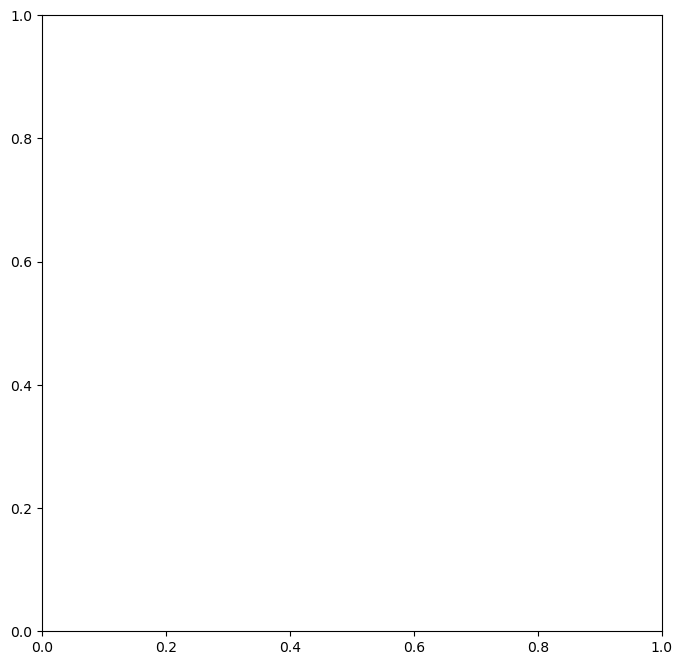

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
rgb_da.plot.imshow(ax=ax, rgb="band", robust=True)
ax.axis("off")
fig.suptitle("20260407_LEVEL2_SEN2C_BOA RGB");
ds.close()